# **Convolution Neural Net**

## **TensorFlow Implementation** 

In [4]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras as nn
from sklearn.datasets import load_sample_image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import convolve2d
import cv2
from tensorflow.keras import layers
# import tensorflow_datasets as tfds
import os
import tensorboard
from sklearn.datasets import fetch_olivetti_faces


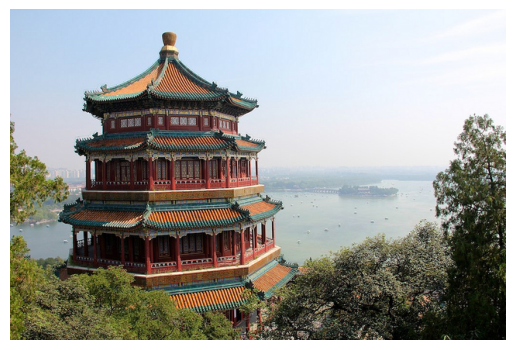

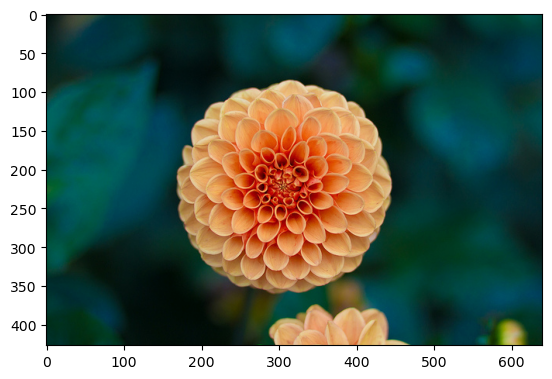

In [77]:
china = load_sample_image("china.jpg") / 255
flower = load_sample_image("flower.jpg") / 255

plt.imshow(china)
plt.axis("off")
plt.show()

plt.imshow(flower)
# plt.axis("off")
plt.show()

In [78]:
images = np.array([china, flower])
batch_size, height, width, channels = images.shape
print(images.shape)

(2, 427, 640, 3)


In [79]:
filters = np.zeros(shape=(3, 3, channels, 2), dtype=np.float32)
filters2 = np.zeros(shape=(5, 5, channels, 2), dtype=np.float32)
filters3 = np.zeros(shape=(7, 7, channels, 2), dtype=np.float32)

In [14]:
filters[:, 1, :, 0] = 1 # vertical line
filters[1, :, :, 1] = 1 # horizontal line

filters2[:, 3, :, 0] = 1 # vertical line
filters2[3, :, :, 1] = 1 # horizontal line

filters3[:, 3, :, 0] = 1 # vertical line
filters3[3, :, :, 1] = 1 # horizontal line

In [15]:
outputs = tf.nn.conv2d(images, filters, strides=1, padding="SAME")
outputs2 = tf.nn.conv2d(images, filters2, strides=3, padding="SAME")
outputs3 = tf.nn.conv2d(images, filters3, strides=5, padding="SAME")

I0000 00:00:1787408364.036490  810601 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1787408364.394082  810601 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1787408364.394905  810601 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1787408364.399824  810601 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

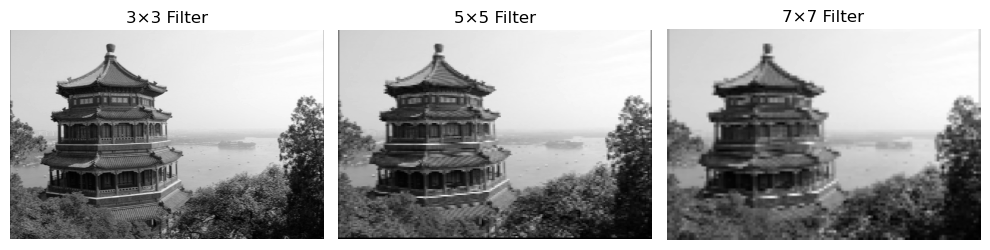

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(10, 8))

ax[0].imshow(outputs[0, :, :, 1], cmap="gray")
ax[0].set_title("3×3 Filter")
ax[0].axis("off")

ax[1].imshow(outputs2[0, :, :, 1], cmap="gray")
ax[1].set_title("5×5 Filter")
ax[1].axis("off")

ax[2].imshow(outputs3[0, :, :, 1], cmap="gray")
ax[2].set_title("7×7 Filter")
ax[2].axis("off")

plt.tight_layout()
plt.show()

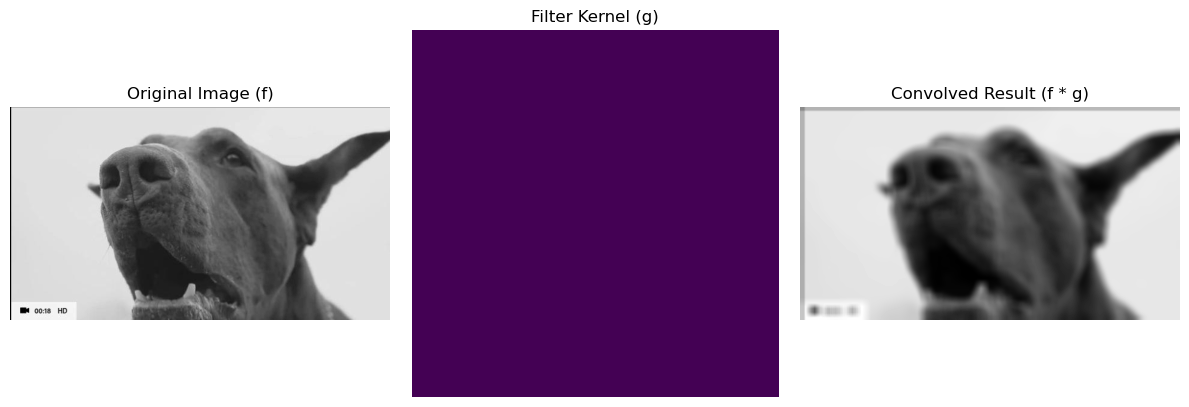

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image in grayscale
image_path = 'TestModel.jpeg'
f = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if f is None:
    f = np.zeros((200, 200), dtype=np.uint8)
    cv2.rectangle(f, (50, 50), (150, 150), 255, -1)

# Normalize to float32 [0.0, 1.0] for precision
f_float = f.astype(np.float32) / 255.0

# 2. Define 15x15 Box Kernel (g)
kernel_size = 15
g = np.ones((kernel_size, kernel_size), dtype=np.float32) / (kernel_size ** 2)

# 3. Apply 2D Convolution using OpenCV
conv_result = cv2.filter2D(f_float, -1, g)

# 4. Display results
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(f, cmap='gray')
axes[0].set_title("Original Image (f)")
axes[0].axis('off')

axes[1].imshow(g, cmap='viridis')
axes[1].set_title("Filter Kernel (g)")
axes[1].axis('off')

axes[2].imshow(conv_result, cmap='gray')
axes[2].set_title("Convolved Result (f * g)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

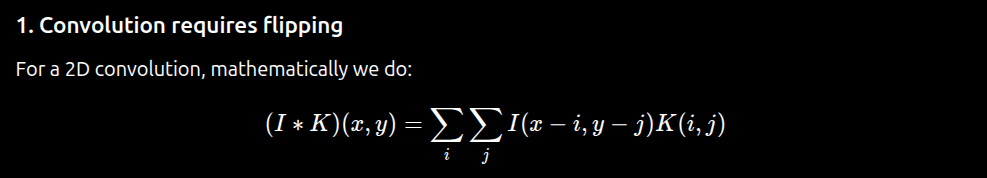

Kernal Filter: 
 [[-1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1.]
 [-1. -1. 24. -1. -1.]
 [-1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1.]]
Kernel Flipped: 
 [[-1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1.]
 [-1. -1. 24. -1. -1.]
 [-1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1.]]
k_height: 
 5
k_width: 
 5
pad_h: 
 2
pad_w: 
 2
padded_img: 
 [[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.00392157 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.08627451 ... 0.8784314  0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


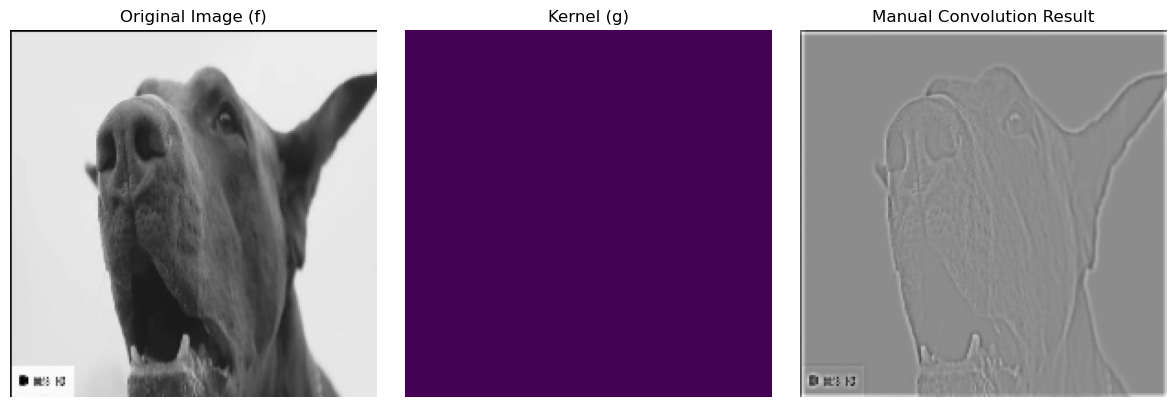

In [18]:
def manual_convolve2d(image, kernel):
    """
    Applies 2D convolution manually using nested loops.
    """
    # 1. Flip the kernel horizontally and vertically for true mathematical convolution
    kernel_flipped = np.flipud(np.fliplr(kernel))
    print("Kernel Flipped: \n", kernel_flipped)
    
    k_height, k_width = kernel.shape
    img_height, img_width = image.shape
    
    # 2. Compute padding sizes for 'same' padding
    pad_h = k_height // 2
    pad_w = k_width // 2
    
    # Pad the image with zeros around the edges
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    print("k_height: \n", k_height)
    print("k_width: \n", k_width)
    
    print("pad_h: \n", pad_h)
    print("pad_w: \n", pad_w)
    
    print("padded_img: \n", padded_img)
    
    # Initialize output array
    output = np.zeros_like(image, dtype=np.float32)
    
    # 3. Slide the kernel across every pixel in the image
    for i in range(img_height):
        
        for j in range(img_width):
        
            # Extract the local image region (sub-matrix) matching the kernel size
            
            region = padded_img[i : i + k_height, j : j + k_width]
            
            # Element-wise multiplication and summation: sum(region * kernel)
            
            output[i, j] = np.sum(region * kernel_flipped)
            
    return output


f = cv2.imread('TestModel.jpeg', cv2.IMREAD_GRAYSCALE)


f = cv2.resize(f, (200, 200)).astype(np.float32) / 255.0

# Define a 7x7 Box Blur Kernel
kernel_size = 5

edge_filter_5x5 = np.array([
    [ 0,  0, -1,  0,  0],
    [ 0, -1, -2, -1,  0],
    [-1, -2, 16, -2, -1],
    [ 0, -1, -2, -1,  0],
    [ 0,  0, -1,  0,  0]
], dtype=np.float32)

edged = np.array([
    [ -1,  -1, -1,  -1,  -1],
    [ 0, 0, 0, 0, 0],
    [ 0, 0, 0, 0, 0],
    [ 0, 0, 0, 0, 0],
    [ 1, 1, 1, 1, 1 ]
], dtype=np.float32)

edge_filter_5x5 = np.array([
    [-1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1],
    [-1, -1, 24, -1, -1],
    [-1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1]
], dtype=np.float32)

g = np.ones((kernel_size, kernel_size), dtype=np.float32) / (kernel_size ** 2)

print("Kernal Filter: \n", edge_filter_5x5)

# Run manual 2D convolution
conv_result_manual = manual_convolve2d(f, edge_filter_5x5)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(f, cmap='gray')
axes[0].set_title("Original Image (f)")
axes[0].axis('off')

axes[1].imshow(g, cmap='viridis')
axes[1].set_title("Kernel (g)")
axes[1].axis('off')

axes[2].imshow(conv_result_manual, cmap='gray')
axes[2].set_title("Manual Convolution Result")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# **Stride Calculation**

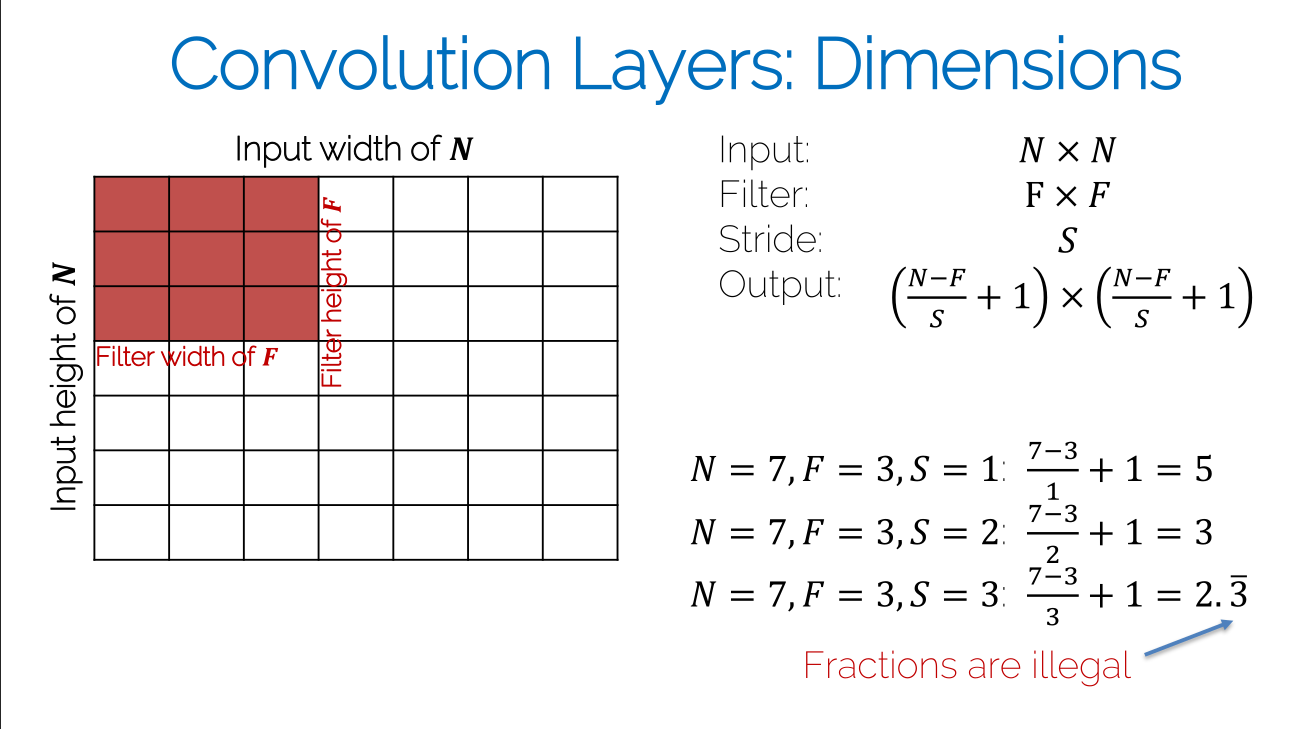

# **Stride With Padding Calculation**

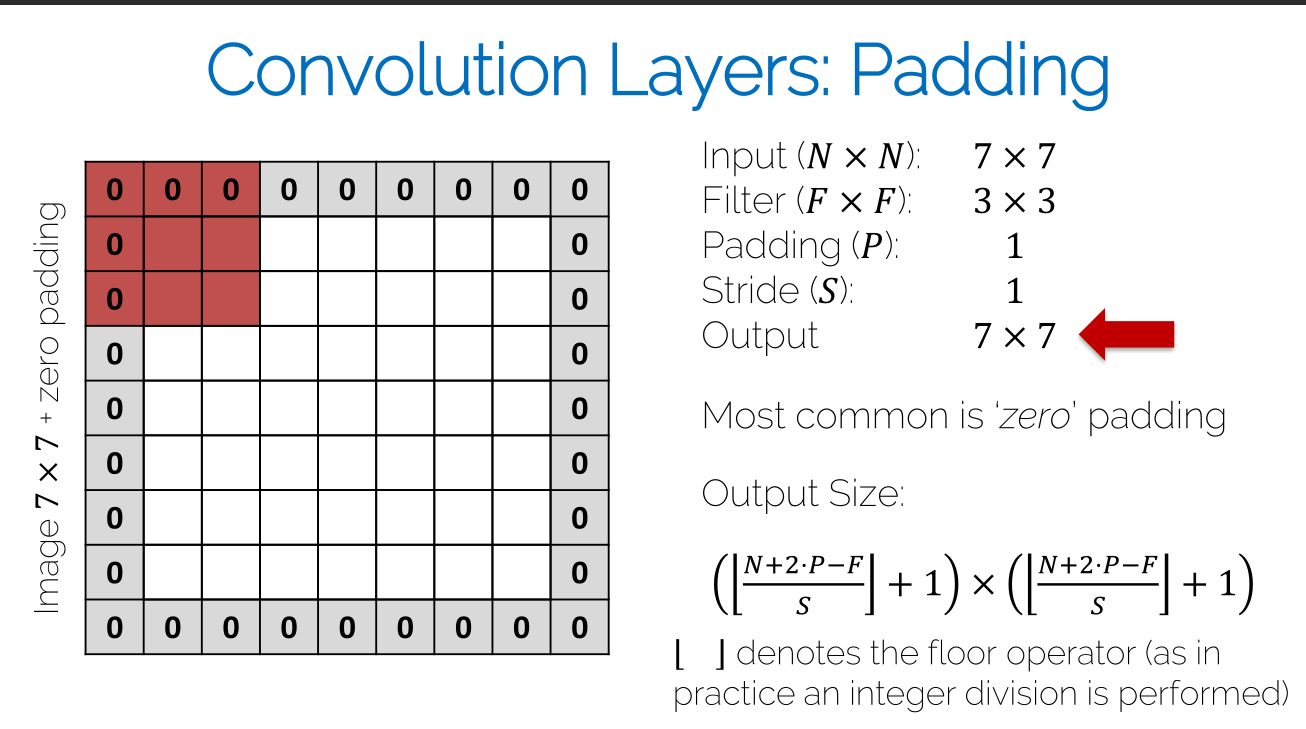

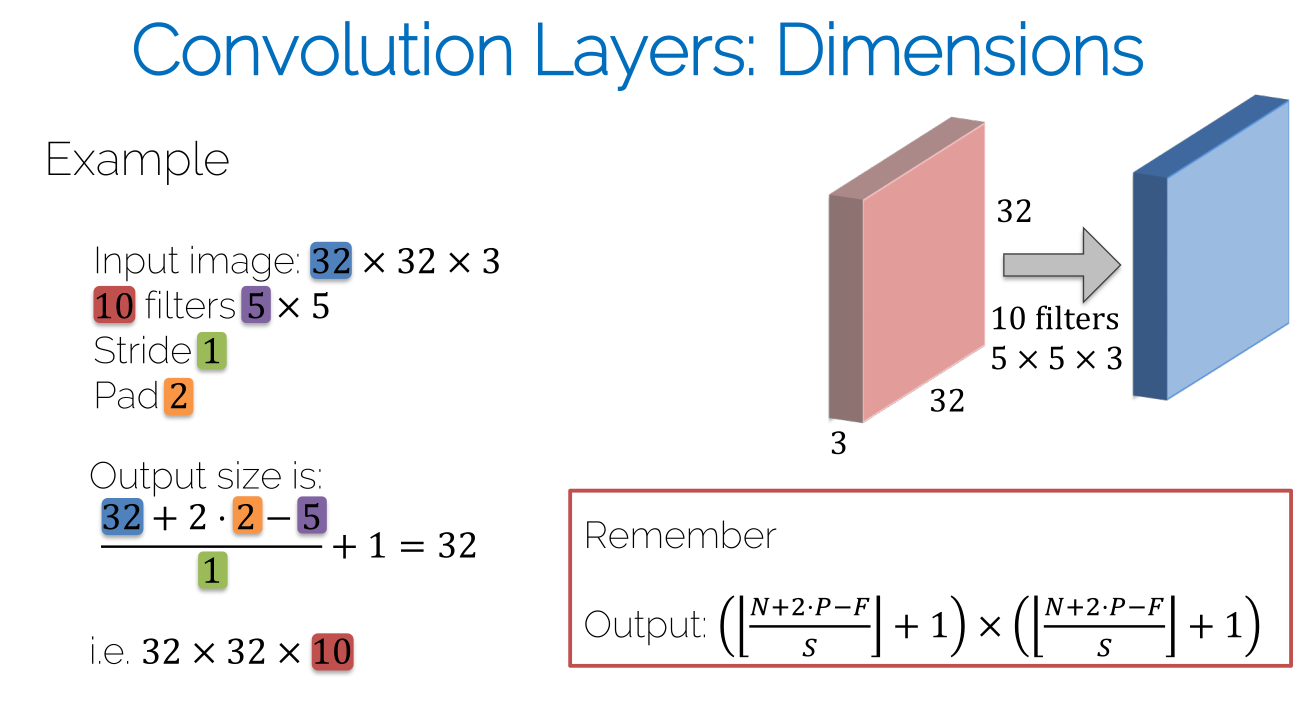

# **Pooling Layer**

## **TensorFlow Implementation**

In [34]:
max_pool = keras.layers.MaxPool2D(pool_size=3, strides=1)

In [35]:
images.shape

(2, 427, 640, 3)

In [36]:
output = tf.nn.max_pool( images, ksize=(1, 3, 3, 1), strides=(1, 3, 3, 1), padding="VALID")

In [37]:
depth_pool = keras.layers.Lambda( lambda X: tf.nn.max_pool(X, ksize=(1, 1, 1, 3), strides=(1, 1, 1, 3), padding="valid"))

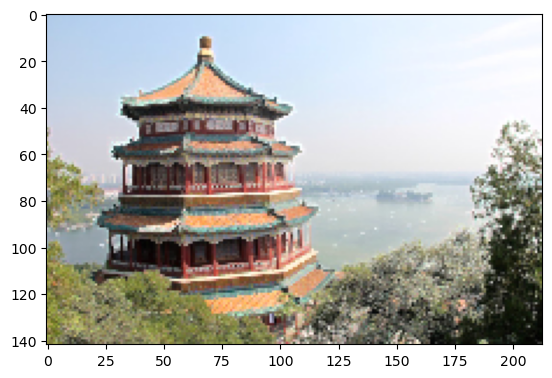

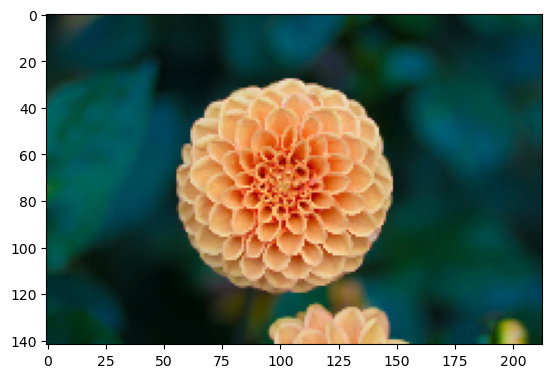

In [41]:
plt.imshow(output[0])
plt.show()
plt.imshow(output[1])
plt.show()

In [43]:
global_avg_pool = keras.layers.GlobalAvgPool2D()

In [47]:
global_avg_pool = keras.layers.Lambda(lambda X: tf.reduce_mean(X, axis=[1, 2]))

output = global_avg_pool(images)

print("Input shape :", images.shape)
print("Output shape:", output.shape)

print("Image 1:", output[0])
print("Image 2:", output[1])

Input shape : (2, 427, 640, 3)
Output shape: (2, 3)
Image 1: tf.Tensor([0.5675281 0.5704654 0.552622 ], shape=(3,), dtype=float32)
Image 2: tf.Tensor([0.21621236 0.2885457  0.22353025], shape=(3,), dtype=float32)


# **CNN Architectures**

In [51]:
tf.keras.backend.clear_session()

In [52]:
model = keras.models.Sequential([
    keras.layers.InputLayer([28, 28, 1]),
    keras.layers.Conv2D(64, 7, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
    keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(256, 3, activation="relu", padding="same"),
    keras.layers.Conv2D(256, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,413,834 (5.39 MB)

 Trainable params: 1,413,834 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

## **Loading and Preprocessing Data:**

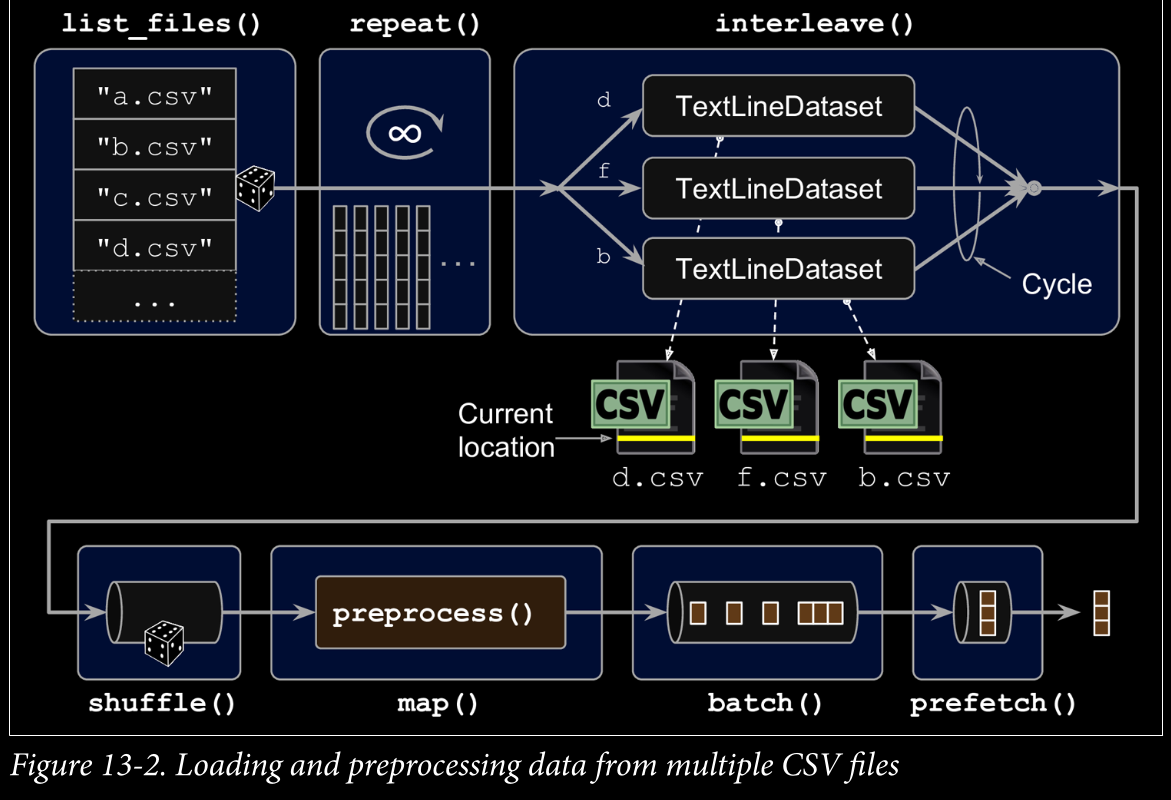

## **LeNet-5 Architecture**

In [55]:
tf.keras.backend.clear_session()
#  Also you can use different Varient like 32, 60, 120, 250, 350, 500 and 800
variant = 800

num_classes = 10

model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 1)),

    # C1
    keras.layers.Conv2D(filters=6, kernel_size=5, activation="tanh"),

    # S2
    keras.layers.AveragePooling2D(pool_size=2, strides=2),

    # C3
    keras.layers.Conv2D(filters=16, kernel_size=5, activation="tanh"),

    # S4
    keras.layers.AveragePooling2D(pool_size=2, strides=2),

    # C5
    keras.layers.Conv2D(filters=120, kernel_size=5, activation="tanh"),

    keras.layers.Flatten(),

    # F6 — 800 units                                     
    keras.layers.Dense(variant, activation="tanh" ),

    # Output
    keras.layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 800)            │        96,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,502 (607.43 KB)

 Trainable params: 155,502 (607.43 KB)

 Non-trainable params: 0 (0.00 B)

## **AlexNet Architectures**

        AlexNet
        AlexNet-A
        AlexNet-B
        AlexNet-C
        AlexNet-D
        AlexNet-E

In [57]:
tf.keras.backend.clear_session()

fc1_units = 4096
fc2_units = 1024       # Change this: 256, 512, 1024, 2048, 4096
num_classes = 1000  # Change according to your dataset

model = keras.Sequential([
    keras.layers.Input(shape=(227, 227, 3)),

    # C1
    keras.layers.Conv2D(filters=96, kernel_size=11, strides=4, activation="relu"),

    # P1
    keras.layers.MaxPooling2D(pool_size=3, strides=2),

    # C2
    keras.layers.Conv2D(filters=256, kernel_size=5, padding="same", activation="relu"),

    # P2
    keras.layers.MaxPooling2D(pool_size=3, strides=2 ),

    # C3
    keras.layers.Conv2D(filters=384, kernel_size=3, padding="same", activation="relu"),

    # C4
    keras.layers.Conv2D(filters=384, kernel_size=3, padding="same", activation="relu"),

    # C5
    keras.layers.Conv2D(filters=256, kernel_size=3, padding="same", activation="relu"),

    # P3
    keras.layers.MaxPooling2D(pool_size=3, strides=2),

    # Classifier
    keras.layers.Flatten(),

    # FC1
    keras.layers.Dense(fc1_units, activation="relu"),

    # FC2
    keras.layers.Dense(fc2_units, activation="relu"),

    # Output
    keras.layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,378,344 (237.95 MB)

 Trainable params: 62,378,344 (237.95 MB)

 Non-trainable params: 0 (0.00 B)

# **SENet**

In [65]:
tf.keras.backend.clear_session()

variant = 64          # Change variant: 32, 64, 128, 256
num_classes = 10

model = keras.Sequential([
    
    keras.layers.Input(shape=(32, 32, 3)),
    
    keras.layers.Conv2D(variant, 3, padding="same", activation="relu"),
    
    keras.layers.GlobalAveragePooling2D(),
    
    keras.layers.Dense(variant // 4, activation="relu"),
    
    keras.layers.Dense(variant, activation="sigmoid"),
    
    keras.layers.Dense(num_classes, activation="softmax")
])

# model.summary()

### **SE-ResNeXt-101**

In [66]:
tf.keras.backend.clear_session()

variant = 101
num_classes = 10


def se_block(x, channels, reduction=16):
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // reduction, activation="relu")(se)
    se = layers.Dense(channels, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])


def se_resnext_block(x, filters, groups=32, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, 1, strides=1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, strides=stride, padding="same", groups=groups, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters * 2, 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    x = se_block(x, filters * 2)

    if shortcut.shape[-1] != filters * 2 or stride != 1:
        shortcut = layers.Conv2D(filters * 2, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    return x


inputs = keras.Input(shape=(224, 224, 3))

x = layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False )(inputs)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.MaxPooling2D( 3, strides=2, padding="same")(x)

# SE-ResNeXt-101
# 3 + 4 + 23 + 3 = 33 bottleneck blocks
for _ in range(3):
    x = se_resnext_block(x, 64)

for _ in range(4):
    x = se_resnext_block(x, 128, stride=2)

for _ in range(23):
    x = se_resnext_block(x, 256, stride=2 if _ == 0 else 1)

for _ in range(3):
    x = se_resnext_block(x, 512, stride=2 if _ == 0 else 1)

x = layers.GlobalAveragePooling2D()(x)

outputs = layers.Dense( num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# model.summary()

# **ResNet Architecture**

    ResNet-18
    ResNet-34
    ResNet-50
    ResNet-101
    ResNet-152

In [68]:
tf.keras.backend.clear_session()

variant = 18          # Change: 18, 34, 50, 101, 152
num_classes = 10


def residual_block(x, filters, stride=1, projection=False):

    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if projection:
        shortcut = layers.Conv2D(filters, 1, strides=stride, use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x


inputs = keras.Input(shape=(224, 224, 3))

x = layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D(3, strides=2, padding="same")(x)


if variant == 18:
    blocks = [2, 2, 2, 2]

elif variant == 34:
    blocks = [3, 4, 6, 3]

elif variant == 50:
    blocks = [3, 4, 6, 3]

elif variant == 101:
    blocks = [3, 4, 23, 3]

elif variant == 152:
    blocks = [3, 8, 36, 3]

else:
    raise ValueError("Variant must be 18, 34, 50, 101, or 152")


filters = [64, 128, 256, 512]

for stage in range(4):
    for block in range(blocks[stage]):
        stride = 2 if stage > 0 and block == 0 else 1

        x = residual_block(x, filters[stage], stride=stride, projection=(stage > 0 and block == 0))


x = layers.GlobalAveragePooling2D()(x)

outputs = layers.Dense( num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]  

 Total params: 11,191,242 (42.69 MB)

 Trainable params: 11,181,642 (42.65 MB)

 Non-trainable params: 9,600 (37.50 KB)

# **Using Pretrained Models from Keras**

    China.jpg ─────────┐
                       │
    Flower.jpg ────────┤
                        ↓
                    (2, 427, 640, 3)
                        ↓
                    Resize 224×224
                        ↓
                    Preprocess
                        ↓
                Pretrained ResNet50
                        ↓
                    (2, 1000)
                        ↓
                    Y_proba
                    ↙       ↘
                argmax       decode_predictions
                ↓                 ↓
            class index       class name

In [97]:
tf.keras.backend.clear_session()

model = keras.applications.resnet50.ResNet50(weights="imagenet")

In [98]:
images_resized = tf.image.resize(images, [224, 224])

inputs = keras.applications.resnet50.preprocess_input( images_resized * 255)

In [99]:
Y_proba = model.predict(inputs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [100]:
print("Y_proba shape:", Y_proba.shape)
print("Y_proba size :", Y_proba.size)

Y_proba shape: (2, 1000)
Y_proba size : 2000


In [102]:
Y_pred = np.argmax(Y_proba, axis=1)
print("Y_pred:", Y_pred)


Y_pred: [442 599]


In [103]:
top_K = keras.applications.resnet50.decode_predictions(Y_proba, top=3)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step


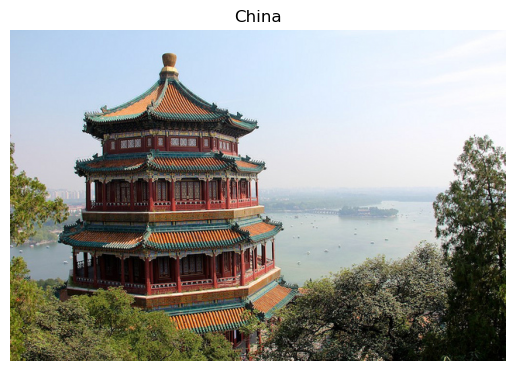

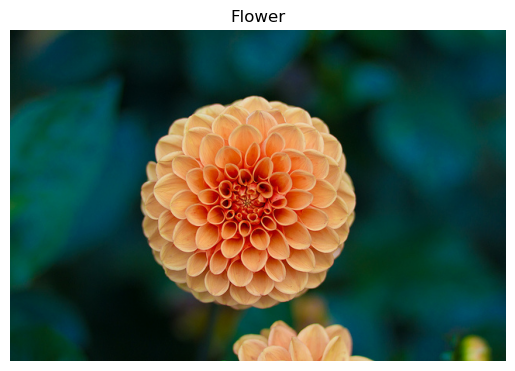

In [106]:
plt.imshow(china)
plt.title("China")
plt.axis("off")
plt.show()

plt.imshow(flower)
plt.title("Flower")
plt.axis("off")
plt.show()

In [104]:
for image_index in range(len(images)):

    print("Image #{}".format(image_index))

    for class_id, name, y_proba in top_K[image_index]:

        print(" {} - {:12s} {:.2f}%".format(class_id, name, y_proba * 100))

    print()

Image #0
 n02825657 - bell_cote    82.35%
 n03877845 - palace       6.75%
 n03781244 - monastery    4.19%

Image #1
 n03530642 - honeycomb    49.81%
 n13040303 - stinkhorn    33.96%
 n02206856 - bee          4.35%



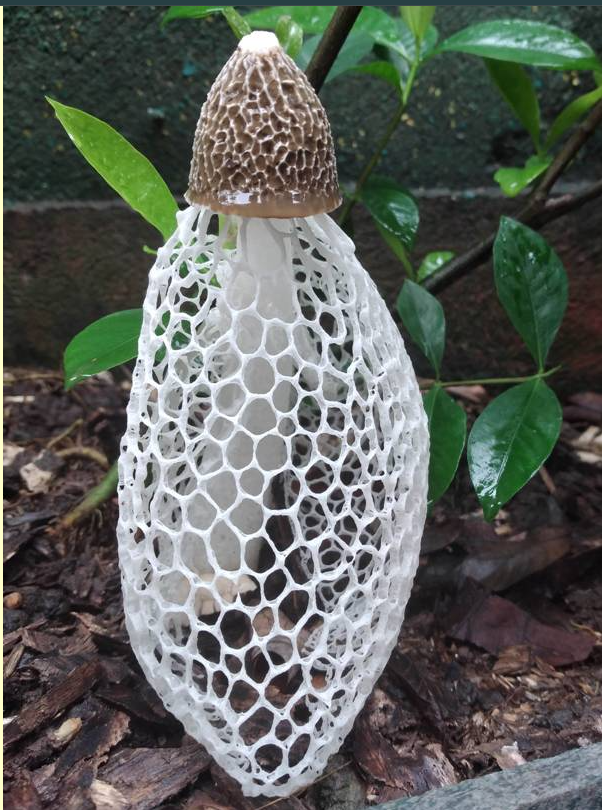 
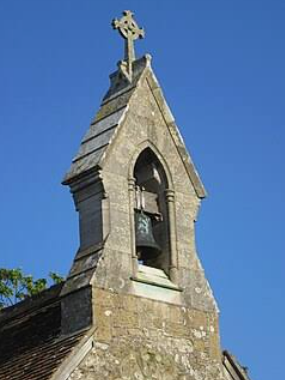
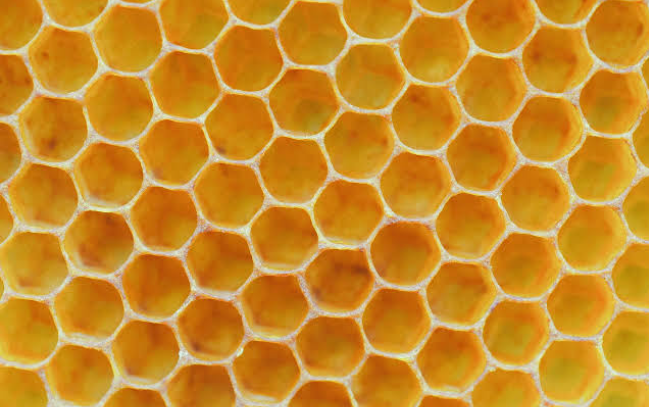

# **Pretrained Models for Transfer Learning**

Xecption_olivetti_faces file in dir

In [ ]:
faces = fetch_olivetti_faces()

X = faces.images          # (400, 64, 64)
y = faces.target          # (400,)

print("X:", X.shape)
print("y:", y.shape)


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Validation / test split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.40, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

In [ ]:
def prepare_images(images):
    images = images[..., np.newaxis]        # (N, 64, 64, 1)

    images = np.repeat(images, 3, axis=-1)

    images = images * 255.0

    # Resize
    images = tf.image.resize(images, (299, 299))

    return images.numpy().astype(np.float32)


X_train = prepare_images(X_train)
X_val = prepare_images(X_val)
X_test = prepare_images(X_test)

print(X_train.shape)

In [ ]:
def _bytes_feature(value):
    return tf.train.Feature(
        bytes_list=tf.train.BytesList(value=[value])
    )

def _int64_feature(value):
    return tf.train.Feature(
        int64_list=tf.train.Int64List(value=[int(value)])
    )

def create_tfrecord(images, labels, filename):

    with tf.io.TFRecordWriter(filename) as writer:

        for image, label in zip(images, labels):

            image_bytes = image.tobytes()

            example = tf.train.Example(
                features=tf.train.Features(
                    feature={
                        "image": _bytes_feature(image_bytes),
                        "label": _int64_feature(label),
                    }
                )
            )

            writer.write(example.SerializeToString())

In [ ]:
create_tfrecord( X_train, y_train, "olivetti_train.tfrecord")

create_tfrecord(X_val, y_val,"olivetti_val.tfrecord")

create_tfrecord(X_test, y_test, "olivetti_test.tfrecord")

In [ ]:
IMAGE_SHAPE = (299, 299, 3)


feature_description = {
    "image": tf.io.FixedLenFeature([], tf.string),
    "label": tf.io.FixedLenFeature([], tf.int64),
}


def parse_tfrecord(example):

    example = tf.io.parse_single_example(
        example,
        feature_description
    )

    image = tf.io.decode_raw(
        example["image"],
        tf.float32
    )

    image = tf.reshape(
        image,
        IMAGE_SHAPE
    )

    label = tf.cast(
        example["label"],
        tf.int32
    )

    return image, label

In [ ]:
BATCH_SIZE = 4


def create_dataset(filename, training=False):

    dataset = tf.data.TFRecordDataset(
        filename,
        num_parallel_reads=tf.data.AUTOTUNE
    )

    dataset = dataset.map(
        parse_tfrecord,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        dataset = dataset.shuffle(
            300,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [ ]:
train_ds = create_dataset("olivetti_train.tfrecord", training=True)

val_ds = create_dataset("olivetti_val.tfrecord")

test_ds = create_dataset("olivetti_test.tfrecord")

In [ ]:

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.10),
    keras.layers.RandomZoom(height_factor=0.15, width_factor=0.15),
    keras.layers.RandomTranslation(height_factor=0.10, width_factor=0.10),
    keras.layers.RandomContrast(0.20),
], name="data_augmentation")


base_model = keras.applications.Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3)
)

inputs = keras.Input(
    shape=(299, 299, 3)
)

x = data_augmentation(inputs)
x = base_model(x)

x = keras.layers.GlobalAveragePooling2D()(x)

x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(40, activation="softmax", kernel_regularizer=keras.regularizers.l2(1e-4))(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "olivetti_face_best_xception.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    mode="min",
    min_lr=1e-7,
    verbose=1
)

In [ ]:
print(tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        print("GPU enabled:", gpus)

    except RuntimeError as e:
        print(e)

else:
    print("No GPU detected.")

In [ ]:
with tf.device("/GPU:0"):

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=150,
        callbacks=[
            checkpoint,
            early_stop,
            reduce_lr
        ]
    )

Epoch 1/150
     75/Unknown 37s 192ms/step - accuracy: 0.0391 - loss: 3.7156/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()

Epoch 1: val_loss improved from None to 3.68092, saving model to olivetti_face_best_xception.keras

Epoch 1: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 41s 239ms/step - accuracy: 0.0400 - loss: 3.7136 - val_accuracy: 0.0667 - val_loss: 3.6809 - learning_rate: 1.0000e-04
Epoch 2/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.0968 - loss: 3.5318
Epoch 2: val_loss improved from 3.68092 to 3.41957, saving model to olivetti_face_best_xception.keras

Epoch 2: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 234ms/step - accuracy: 0.1333 - loss: 3.3919 - val_accuracy: 0.1500 - val_loss: 3.4196 - learning_rate: 1.0000e-04
Epoch 3/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.3139 - loss: 2.8333
Epoch 3: val_loss improved from 3.41957 to 2.46480, saving model to olivetti_face_best_xception.keras

Epoch 3: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 234ms/step - accuracy: 0.3367 - loss: 2.7589 - val_accuracy: 0.6500 - val_loss: 2.4648 - learning_rate: 1.0000e-04
Epoch 4/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.6577 - loss: 2.1736
Epoch 4: val_loss improved from 2.46480 to 1.47443, saving model to olivetti_face_best_xception.keras

Epoch 4: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - accuracy: 0.6833 - loss: 2.0208 - val_accuracy: 0.8167 - val_loss: 1.4744 - learning_rate: 1.0000e-04
Epoch 5/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.8199 - loss: 1.5377
Epoch 5: val_loss improved from 1.47443 to 0.65436, saving model to olivetti_face_best_xception.keras

Epoch 5: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 238ms/step - accuracy: 0.8200 - loss: 1.4197 - val_accuracy: 0.9833 - val_loss: 0.6544 - learning_rate: 1.0000e-04
Epoch 6/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9168 - loss: 1.0485
Epoch 6: val_loss improved from 0.65436 to 0.33087, saving model to olivetti_face_best_xception.keras

Epoch 6: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 236ms/step - accuracy: 0.9333 - loss: 0.9283 - val_accuracy: 0.9833 - val_loss: 0.3309 - learning_rate: 1.0000e-04
Epoch 7/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9358 - loss: 0.7034
Epoch 7: val_loss improved from 0.33087 to 0.18461, saving model to olivetti_face_best_xception.keras

Epoch 7: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 234ms/step - accuracy: 0.9333 - loss: 0.7165 - val_accuracy: 0.9833 - val_loss: 0.1846 - learning_rate: 1.0000e-04
Epoch 8/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9598 - loss: 0.4741
Epoch 8: val_loss improved from 0.18461 to 0.12833, saving model to olivetti_face_best_xception.keras

Epoch 8: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 236ms/step - accuracy: 0.9467 - loss: 0.5153 - val_accuracy: 0.9833 - val_loss: 0.1283 - learning_rate: 1.0000e-04
Epoch 9/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9861 - loss: 0.3414
Epoch 9: val_loss improved from 0.12833 to 0.08688, saving model to olivetti_face_best_xception.keras

Epoch 9: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 237ms/step - accuracy: 0.9833 - loss: 0.3358 - val_accuracy: 0.9833 - val_loss: 0.0869 - learning_rate: 1.0000e-04
Epoch 10/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9949 - loss: 0.1924
Epoch 10: val_loss improved from 0.08688 to 0.05567, saving model to olivetti_face_best_xception.keras

Epoch 10: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 294ms/step - accuracy: 0.9900 - loss: 0.2180 - val_accuracy: 0.9833 - val_loss: 0.0557 - learning_rate: 1.0000e-04
Epoch 11/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 1.0000 - loss: 0.1304
Epoch 11: val_loss improved from 0.05567 to 0.04990, saving model to olivetti_face_best_xception.keras

Epoch 11: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 234ms/step - accuracy: 1.0000 - loss: 0.1380 - val_accuracy: 0.9833 - val_loss: 0.0499 - learning_rate: 1.0000e-04
Epoch 12/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9917 - loss: 0.1405
Epoch 12: val_loss improved from 0.04990 to 0.04660, saving model to olivetti_face_best_xception.keras

Epoch 12: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - accuracy: 0.9933 - loss: 0.1246 - val_accuracy: 0.9833 - val_loss: 0.0466 - learning_rate: 1.0000e-04
Epoch 13/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9874 - loss: 0.1390
Epoch 13: val_loss did not improve from 0.04660
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 216ms/step - accuracy: 0.9800 - loss: 0.1706 - val_accuracy: 0.9833 - val_loss: 0.0717 - learning_rate: 1.0000e-04
Epoch 14/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9979 - loss: 0.1006
Epoch 14: val_loss improved from 0.04660 to 0.03518, saving model to olivetti_face_best_xception.keras

Epoch 14: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 303ms/step - accuracy: 0.9967 - loss: 0.1027 - val_accuracy: 0.9833 - val_loss: 0.0352 - learning_rate: 1.0000e-04
Epoch 15/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9906 - loss: 0.0811
Epoch 15: val_loss did not improve from 0.03518
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 213ms/step - accuracy: 0.9967 - loss: 0.0716 - val_accuracy: 0.9833 - val_loss: 0.0484 - learning_rate: 1.0000e-04
Epoch 16/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9994 - loss: 0.0579
Epoch 16: val_loss did not improve from 0.03518
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 225ms/step - accuracy: 0.9967 - loss: 0.0729 - val_accuracy: 0.9833 - val_loss: 0.0618 - learning_rate: 1.0000e-04
Epoch 17/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9960 - loss: 0.0816
Epoch 17: val_loss did not improve from 0.03518

Epoch 17: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 218ms/step - accuracy: 0.9967 - loss: 0.0844 - val_accuracy: 0.9667 - val_loss: 0.1575 - learning_rate: 1.0000e-04
Epoch 18/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9986 - loss: 0.0674
Epoch 18: val_loss improved from 0.03518 to 0.03291, saving model to olivetti_face_best_xception.keras

Epoch 18: finished saving model to olivetti_face_best_xception.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.9967 - loss: 0.0691 - val_accuracy: 1.0000 - val_loss: 0.0329 - learning_rate: 5.0000e-05
Epoch 19/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 1.0000 - loss: 0.0771
Epoch 19: val_loss did not improve from 0.03291
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 214ms/step - accuracy: 1.0000 - loss: 0.0647 - val_accuracy: 0.9833 - val_loss: 0.0524 - learning_rate: 5.0000e-05
Epoch 20/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 1.0000 - loss: 0.0568
Epoch 20: val_loss did not improve from 0.03291
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 216ms/step - accuracy: 1.0000 - loss: 0.0590 - val_accuracy: 0.9833 - val_loss: 0.0575 - learning_rate: 5.0000e-05
Epoch 21/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 1.0000 - loss: 0.0511
Epoch 21: val_loss did not improve from 0.03291

Epoch 21: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 217ms/step - accuracy: 1.0000 - loss: 0.0560 - val_accuracy: 0.9833 - val_loss: 0.0520 - learning_rate: 5.0000e-05
Epoch 22/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9870 - loss: 0.0739
Epoch 22: val_loss did not improve from 0.03291
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 217ms/step - accuracy: 0.9967 - loss: 0.0518 - val_accuracy: 0.9833 - val_loss: 0.0539 - learning_rate: 2.5000e-05
Epoch 23/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 1.0000 - loss: 0.0478
Epoch 23: val_loss did not improve from 0.03291
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 215ms/step - accuracy: 1.0000 - loss: 0.0429 - val_accuracy: 0.9833 - val_loss: 0.0545 - learning_rate: 2.5000e-05
Epoch 24/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 1.0000 - loss: 0.0394
Epoch 24: val_loss did not improve from 0.03291

Epoch 24: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 213ms/step - accuracy: 1.0000 - loss: 0.0473 - val_accuracy: 0.9833 - val_loss: 0.0573 - learning_rate: 2.5000e-05
Epoch 25/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9985 - loss: 0.0577
Epoch 25: val_loss did not improve from 0.03291
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 216ms/step - accuracy: 0.9967 - loss: 0.0632 - val_accuracy: 0.9833 - val_loss: 0.0515 - learning_rate: 1.2500e-05
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 18.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Xception Training and Validation Metrics")

plt.legend()
plt.grid(True)

plt.show()

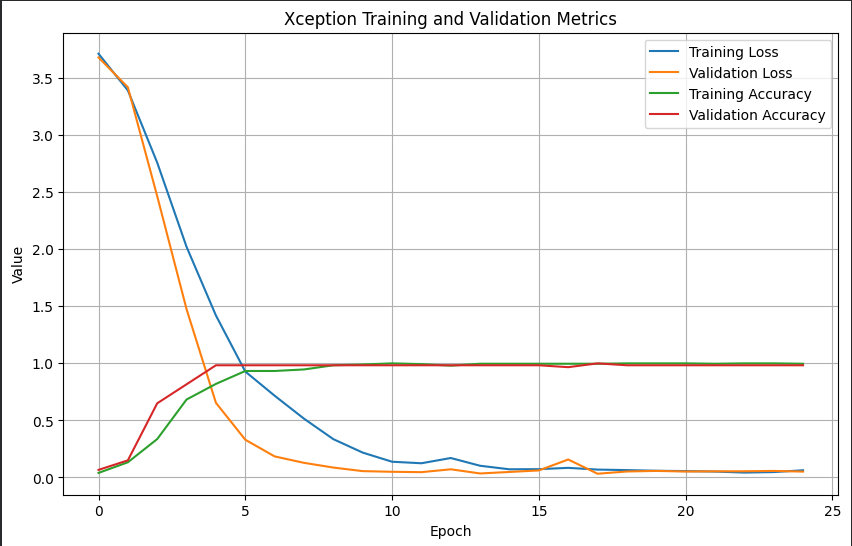

# **Dilation Rate**

### **dilation rate as the spacing between pixels that a CNN looks at.**
#### **Simple example**
```
Conv2D(
    filters=64,
    kernel_size=3,
    dilation_rate=2,
    padding="same"
)
```

A normal 3×3 CNN filter with dilation = 1:
```
XXX
XXX
XXX
```
It looks at pixels next to each other.

With dilation = 2: `dot -> 0`
```
X.X.X
.....
X.X.X
.....
X.X.X
```

Now it skips one pixel between each point.

Why?

It lets the CNN see a larger area of the image without making the filter bigger.
```
Dilation = 1 → sees a small area
Dilation = 2 → sees a bigger area
Dilation = 3 → sees an even bigger area
```
So, in one sentence:

**Dilation rate controls how far apart the pixels are that the CNN filter looks at.**

- Think of it like zooming your view outward without adding more filter weights.